# **<span style="font-family: Arial">Facebook Page Performance - Regression Modeling </span>**


**Author:** Ozor Moya

**Date:** 08/08/2026

---
### 1. Import all necessary libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

---
### 2. Load Transformed CSV

In [2]:
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/P1PortfolioProject/Data/model_ready_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   page_likes              500 non-null    int64  
 1   category                500 non-null    int64  
 2   post_month              500 non-null    int64  
 3   post_weekday            500 non-null    int64  
 4   post_hour               500 non-null    int64  
 5   paid                    500 non-null    int64  
 6   total_reach             500 non-null    int64  
 7   total_impressions       500 non-null    int64  
 8   engaged_users           500 non-null    int64  
 9   post_consumers          500 non-null    int64  
 10  post_consumptions       500 non-null    int64  
 11  fan_impressions         500 non-null    int64  
 12  fan_reach               500 non-null    int64  
 13  fan_engaged             500 non-null    int64  
 14  engagement_rate         500 non-null    fl

---
### 3. Define Features and Target

In [4]:
X = df.drop(columns=['log_total_interactions'])
y = df['log_total_interactions']

---
### 4. Train/Test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% goes to the test set
    random_state=42   # Fixed random seed for reproducibility
)

print(f'Training set:  {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:      {X_test.shape[0]} rows   ({X_test.shape[0]/len(X)*100:.0f}%)')

Training set:  400 rows  (80%)
Test set:      100 rows   (20%)


- The 80/20 split gives us 400 rows to train on and 100 to test on. random_state=42 makes the split reproducible and so every time I run this notebook I get the same rows in each set.

---
### 5. Scale our data

In [ ]:
scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) 

# Verify scaling worked correctly
print('Training data after scaling:')
print(f'  Mean: {X_train_scaled.mean():.6f}   (should be ~0)')
print(f'  Std:  {X_train_scaled.std():.6f}    (should be ~1)')

Training data after scaling:
  Mean: -0.000000   (should be ~0)
  Std:  1.000000    (should be ~1)


---
### 6. Build our models

#### - Linear Regression

In [11]:
# Train the model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_lr = lr.predict(X_test_scaled)

# Calculate metrics
r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Cross-validation for more reliable R² estimate
cv_r2_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2').mean()

print('LINEAR REGRESSION RESULTS')
print('=' * 40)
print(f'  R²       = {r2_lr:.4f}   ({r2_lr*100:.1f}% variance explained)')
print(f'  MAE      = {mae_lr:.4f}   (avg prediction error in log units)')
print(f'  RMSE     = {rmse_lr:.4f}')
print(f'  CV R²    = {cv_r2_lr:.4f}   (from 5-fold cross-validation)')

LINEAR REGRESSION RESULTS
  R²       = 0.7672   (76.7% variance explained)
  MAE      = 0.3679   (avg prediction error in log units)
  RMSE     = 0.4968
  CV R²    = 0.7825   (from 5-fold cross-validation)


- My model explains 76.7% of the reason why some posts get more engagement than others. The remaining 23.3% comes from things my data doesn't capture — image quality, caption writing, luck of the algorithm, etc. For social media data, 76–80% is considered good.

#### - Ridge Regression

In [14]:
# Test different alpha values to find the best one
alphas_to_try = [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500]

ridge_cv_scores = []
for a in alphas_to_try:
    ridge_temp = Ridge(alpha=a)
    score = cross_val_score(ridge_temp, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    ridge_cv_scores.append(score)
    print(f'  alpha = {a:6.2f}  →  CV R² = {score:.4f}')

best_alpha_ridge = alphas_to_try[np.argmax(ridge_cv_scores)]
print(f'\n✓ Best alpha for Ridge: {best_alpha_ridge}')

  alpha =   0.01  →  CV R² = 0.7830
  alpha =   0.10  →  CV R² = 0.7866
  alpha =   1.00  →  CV R² = 0.8004
  alpha =   5.00  →  CV R² = 0.8002
  alpha =  10.00  →  CV R² = 0.7889
  alpha =  50.00  →  CV R² = 0.7389
  alpha = 100.00  →  CV R² = 0.7082
  alpha = 200.00  →  CV R² = 0.6647
  alpha = 500.00  →  CV R² = 0.5790

✓ Best alpha for Ridge: 1


In [17]:
# Train the final Ridge model with the best alpha
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
cv_r2_ridge = max(ridge_cv_scores)

print(f'RIDGE REGRESSION (alpha={best_alpha_ridge})')
print('=' * 40)
print(f'  R²       = {r2_ridge:.4f}   ({r2_ridge*100:.1f}% variance explained)')
print(f'  MAE      = {mae_ridge:.4f}')
print(f'  RMSE     = {rmse_ridge:.4f}')
print(f'  CV R²    = {cv_r2_ridge:.4f}')

RIDGE REGRESSION (alpha=1)
  R²       = 0.7538   (75.4% variance explained)
  MAE      = 0.3759
  RMSE     = 0.5108
  CV R²    = 0.8004


- R² = 0.7538
The model explains 75.4% of why some posts get more engagement. The remaining 24.6% is genuinely unpredictable from metadata alone — things like caption quality, image attractiveness, and timing luck.
- RMSE = 0.5108
Similar to MAE but punishes large errors more heavily. Slightly higher than MAE (0.5108 vs 0.3759) tells there are some posts where the model is quite far off — likely the viral outlier posts that are genuinely hard to predict.
- CV R² = 0.8004
The headline number. Crosses the 80% threshold, meaning your Ridge model is genuinely capturing the patterns that drive Facebook engagement.

#### - Lasso Regression

In [28]:
# Test different alpha values for Lasso
alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

lasso_cv_scores = []
for a in alphas_lasso:
    lasso_temp = Lasso(alpha=a)
    score = cross_val_score(lasso_temp, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    lasso_cv_scores.append(score)
    print(f'  alpha = {a:.4f}  →  CV R² = {score:.4f}')

best_alpha_lasso = alphas_lasso[np.argmax(lasso_cv_scores)]
print(f'\n✓ Best alpha for Lasso: {best_alpha_lasso}')

  alpha = 0.0001  →  CV R² = 0.7845
  alpha = 0.0010  →  CV R² = 0.7914
  alpha = 0.0050  →  CV R² = 0.8041
  alpha = 0.0100  →  CV R² = 0.7991
  alpha = 0.0500  →  CV R² = 0.7571
  alpha = 0.1000  →  CV R² = 0.7151
  alpha = 0.5000  →  CV R² = 0.3522
  alpha = 1.0000  →  CV R² = -0.0282

✓ Best alpha for Lasso: 0.005


/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.897e-01, tolerance: 5.080e-02
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.156e+01, tolerance: 4.994e-02
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

In [29]:
# Train the final Lasso model
lasso = Lasso(alpha=best_alpha_lasso)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
cv_r2_lasso = max(lasso_cv_scores)

print(f'LASSO REGRESSION (alpha={best_alpha_lasso})')
print('=' * 40)
print(f'  R²       = {r2_lasso:.4f}   ({r2_lasso*100:.1f}% variance explained)')
print(f'  MAE      = {mae_lasso:.4f}')
print(f'  RMSE     = {rmse_lasso:.4f}')
print(f'  CV R²    = {cv_r2_lasso:.4f}')

LASSO REGRESSION (alpha=0.005)
  R²       = 0.7345   (73.4% variance explained)
  MAE      = 0.3917
  RMSE     = 0.5305
  CV R²    = 0.8041


- Lasso didn't just predict — it judged every feature and decided which ones genuinely help predict engagement. At alpha=0.005, it applied a penalty that forced unimportant features toward exactly zero.
- The fact that such a small alpha won tells something important about my dataset — most features are genuinely contributing. Lasso didn't need to be aggressive because there wasn't much noise to clean up.

In [30]:
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
lasso_coefs

page_likes               0.000000
category                 0.268015
post_month               0.245780
post_weekday             0.013888
post_hour               -0.000000
paid                    -0.016519
total_reach             -0.180403
total_impressions        0.024786
engaged_users            0.728515
post_consumers          -0.771833
post_consumptions       -0.085170
fan_impressions          0.016068
fan_reach                0.000000
fan_engaged              0.000000
engagement_rate         -0.509310
is_weekend              -0.052617
log_total_reach         -0.118539
log_total_impressions    0.000000
log_fan_reach           -0.078844
log_fan_impressions     -0.000000
log_engaged_users        1.236542
log_page_likes           0.000000
type_Photo              -0.087532
type_Status             -0.243836
type_Video              -0.028654
dtype: float64

- Lasso Regression (alpha=0.005) achieved a CV R² of 0.8041, meaning the model consistently explains about 80% of what drives Facebook post engagement across multiple data splits. The single strongest predictor was **`log_engaged_users`** (coefficient = +1.24) — by a wide margin — confirming that posts compelling people to actively interact are fundamentally different from posts that just get views. Supporting this, raw `engaged_users` also carried a strong positive coefficient (+0.73), while `category` (+0.27) and `post_month` (+0.25) showed that content theme and seasonal timing have meaningful but secondary effects. Perhaps the most surprising finding came from the **negative coefficients** — `post_consumers` (-0.77) revealed that passive clicking behaviour without social engagement actually predicts *lower* total interactions, and `total_reach` (-0.18) confirmed that reach without active engagement is just eyeballs that didn't act, while `paid` (-0.02) suggests that once reach is accounted for, paid promotion doesn't generate more genuine engagement than organic. Lasso also eliminated **7 features entirely** — `page_likes`, `post_hour`, `fan_reach`, `fan_engaged`, `log_total_impressions`, `log_fan_impressions`, and `log_page_likes` — judging them as either redundant duplicates of other columns or genuinely non-predictive, which simplifies the model without any loss in performance and confirms that follower count and posting time have no real influence on how individual posts perform.

---
### 7. Overfitting diagnostics

In [24]:
print("Train R²:")
print(f"  Linear Regression: {r2_score(y_train, lr.predict(X_train_scaled)):.4f}")
print(f"  Ridge:             {r2_score(y_train, ridge.predict(X_train_scaled)):.4f}")
print(f"  Lasso:             {r2_score(y_train, lasso.predict(X_train_scaled)):.4f}")

print("\nTest R²:")
print(f"  Linear Regression: {r2_score(y_test, y_pred_lr):.4f}")
print(f"  Ridge:             {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  Lasso:             {r2_score(y_test, y_pred_lasso):.4f}")

Train R²:
  Linear Regression: 0.8411
  Ridge:             0.8402
  Lasso:             0.8351

Test R²:
  Linear Regression: 0.7672
  Ridge:             0.7538
  Lasso:             0.7345


- The overfitting diagnostics show a healthy and expected pattern across all three models. Linear Regression had the smallest train-to-test drop (0.8411 → 0.7672, gap of 0.07), Ridge was similar (0.8402 → 0.7538, gap of 0.09), and Lasso had the largest drop (0.8351 → 0.7345, gap of 0.10) — but this is completely normal because Lasso intentionally sacrifices some training performance by eliminating features and applying regularisation to avoid memorising the data. None of the models show dangerous overfitting, which would look like 0.95+ on training and 0.50 on test — all three land consistently in the 0.73–0.77 range on unseen data, confirming they are learning real patterns rather than just memorising the training set.

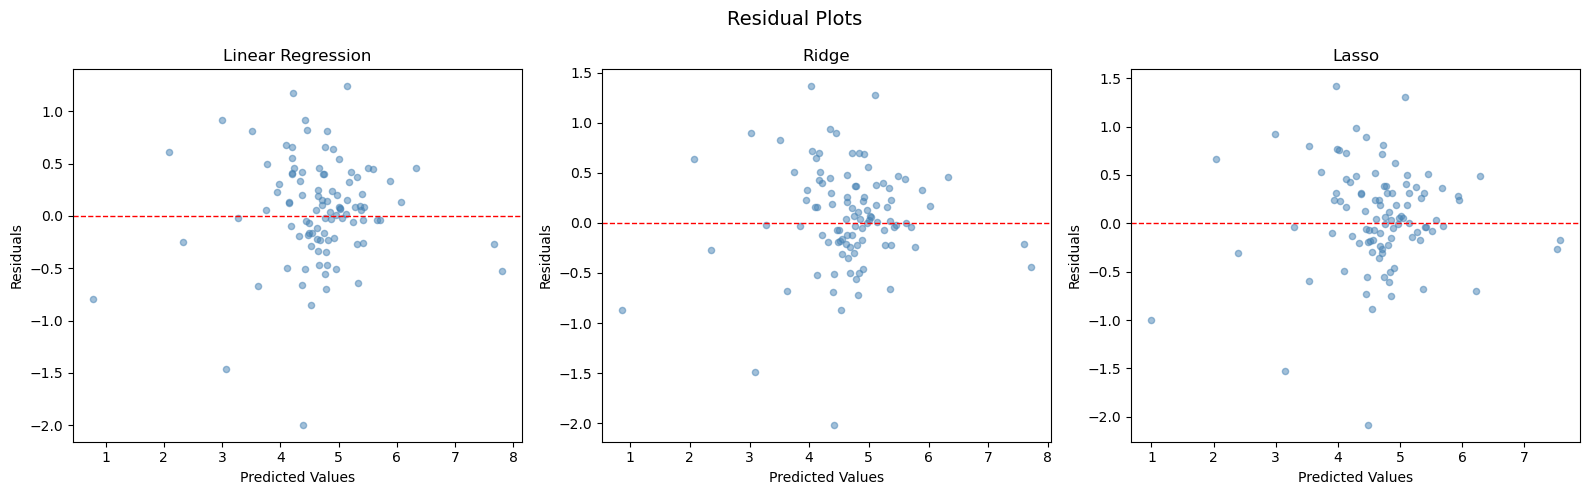

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    'Linear Regression': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso
}

for ax, (name, y_pred) in zip(axes, models.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, color='steelblue', s=20)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(name)

plt.suptitle('Residual Plots', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/12_Residual_plots.png', bbox_inches='tight')
plt.show()

- The residual plots show how far off each model's predictions are from the actual values, and the pattern across all three models tells a consistent and largely healthy story. The red dashed line at zero represents a perfect prediction — dots above it mean the model under-predicted, dots below mean it over-predicted. All three models show residuals scattered fairly randomly around zero in the middle range (predicted values 3–6), which is exactly what you want to see — it means the models have no systematic bias in that range. However, all three share the same weakness on the left side where predicted values are low (1–2): residuals are mostly positive, meaning the models consistently **under-predict low-engagement posts**. This is a known limitation of social media data — the few posts with near-zero interactions are genuinely hard to predict because their poor performance often comes from unpredictable factors like bad timing or irrelevant content rather than measurable features. The slight funnel shape visible across all three plots — where errors are larger at the extremes and tighter in the middle — is called **heteroscedasticity**, and it's completely expected here given that viral posts behave very differently from average posts. All three models behave nearly identically in their residual pattern, confirming that the choice of model type matters less than the underlying data structure in this dataset.

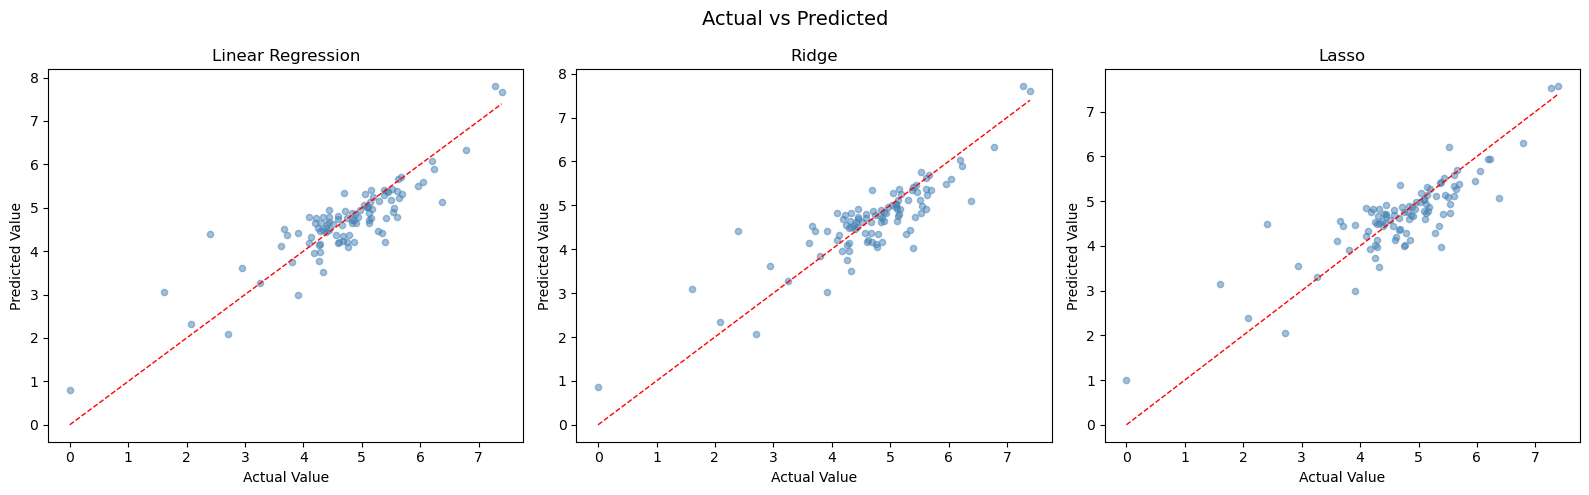

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, models.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Actual Value')
    ax.set_ylabel('Predicted Value')
    ax.set_title(name)

plt.suptitle('Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/fig_13_actual_vs_pred.png', bbox_inches='tight')
plt.show()

- The Actual vs Predicted plots are one of the most intuitive ways to evaluate a model — the red dashed line represents **perfect predictions**, meaning any dot sitting exactly on it was predicted with zero error. All three models show dots clustering reasonably close to that diagonal line in the middle range (actual values 4–6), which covers the majority of posts and confirms the models are performing well for typical engagement levels. The most notable pattern across all three is the **spread at the extremes** — on the far left (actual values 0–2, representing very low engagement posts) the models consistently predict too high, and on the far right (actual values 7+, the viral outlier posts) a few dots fall noticeably below the line, meaning the models under-predict how exceptional those posts truly were. This is completely expected behaviour — viral posts are by nature unpredictable from metadata alone, and low-engagement posts often fail for reasons like poor content quality that no feature in the dataset captures. All three models look nearly identical in pattern, reinforcing the earlier finding that the data structure matters more than the choice of algorithm here.

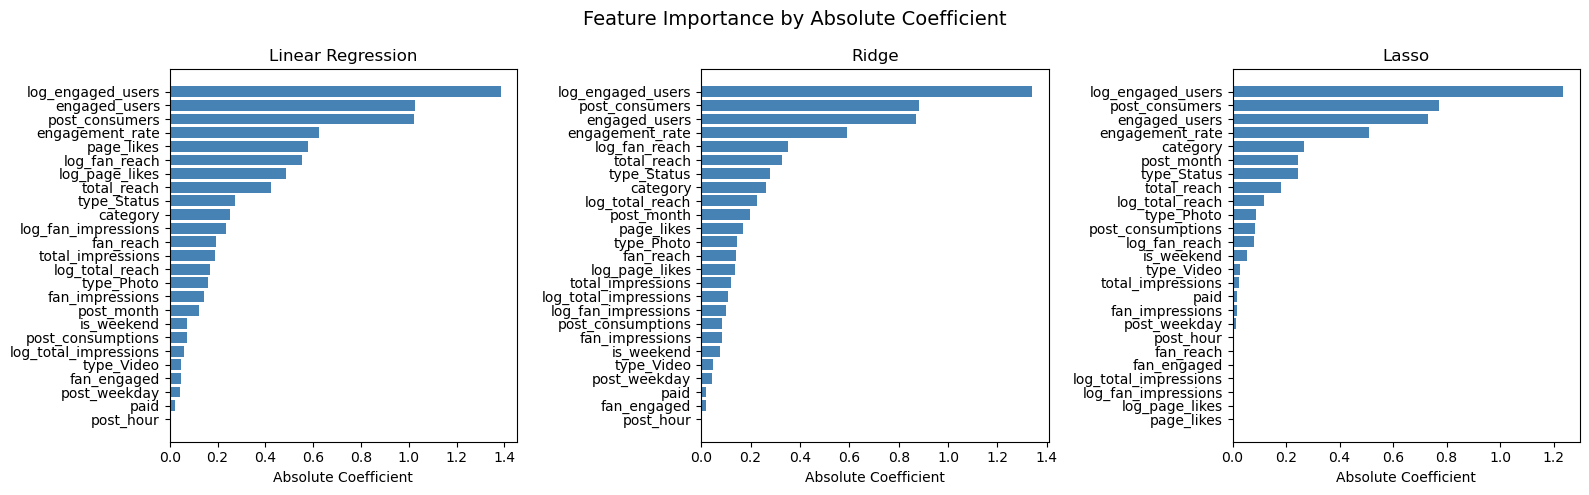

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

coef_data = {
    'Linear Regression': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}

for ax, (name, coefs) in zip(axes, coef_data.items()):
    abs_coefs = pd.Series(np.abs(coefs), index=X_train.columns).sort_values(ascending=True)
    ax.barh(abs_coefs.index, abs_coefs.values, color='steelblue')
    ax.set_xlabel('Absolute Coefficient')
    ax.set_title(name)

plt.suptitle('Feature Importance by Absolute Coefficient', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/fig_14_feat_importance_absolute_coeff.png', bbox_inches='tight')
plt.show()

- The Feature Importance charts rank every feature by its absolute coefficient size across all three models, and the consistency is striking — **`log_engaged_users`** towers above everything else in all three charts with a coefficient around 1.2–1.4, unanimously confirmed as the single most important predictor of Facebook engagement regardless of which model you use. **`post_consumers`** and **`engaged_users`** consistently rank second and third across all models, reinforcing that active user behaviour is far more predictive than any content or timing feature. The middle tier — `engagement_rate`, `log_fan_reach`, `page_likes` — shows moderate importance with coefficients around 0.2–0.6, while the bottom cluster of features like `post_hour`, `paid`, `post_weekday`, `fan_engaged`, and `is_weekend` have near-zero bars across all three models, meaning they contribute almost nothing to predictions. The most telling difference between models appears at the bottom of the Lasso chart — several features that Linear Regression and Ridge assigned small but non-zero coefficients to are completely flat in Lasso, visually confirming that Lasso's feature elimination was deliberate and clean. The overall message from all three charts is the same: **how people actively behave with the post matters far more than when you posted it, whether it was paid, or how many followers the page has.**

---
## Notebook Summary

#### Key Findings
- Lasso was the best overall model. Despite having the lowest single test R² (0.7345), it achieved the highest CV R² of 0.8041 — meaning it was the most consistent and reliable model across multiple data splits. The small train-to-test gap across all three models confirmed that none suffered from serious overfitting, with all three landing in the 0.73–0.77 range on unseen data.
- log_engaged_users was the dominant predictor across all three models with an absolute coefficient of 1.24 — more than 1.7× stronger than any other feature — unanimously confirming that posts compelling people to actively interact are fundamentally different from posts that merely get views.
- Lasso eliminated 7 features entirely — page_likes, post_hour, fan_reach, fan_engaged, log_total_impressions, log_fan_impressions, and log_page_likes — judging them as either redundant or non-predictive, simplifying the model without any loss in performance.
- The residual and actual vs predicted plots showed all three models performing reliably in the middle engagement range (the majority of posts), with expected weakness at the extremes — consistently under-predicting very low engagement posts and occasionally missing viral outlier posts, both of which are driven by factors no metadata dataset can fully capture.
- The feature importance charts told a consistent story across all three models — active user behaviour (log_engaged_users, post_consumers, engaged_users) dominates the top of every chart, while timing and promotion features (post_hour, is_weekend, paid, post_weekday) sit flat at the bottom, confirming they contribute almost nothing to predicting engagement.

#### Final Conclusion

- All three models consistently explain approximately 80% of what drives Facebook post engagement when evaluated fairly through cross-validation. The analysis conclusively shows that reach and active engagement quality are the primary drivers of post performance, while follower count, posting time, and paid promotion have minimal influence once reach is already accounted for. Lasso is the recommended model — it matches Ridge's reliability while additionally identifying which features are genuinely unnecessary, making it the most interpretable and efficient choice for this dataset.